In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))





In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0




In [ ]:
X_train

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


# 32 filters → It learns 32 different patterns (edges, shapes).

# (3,3) → Filter size (small window scanning the image).

# activation='relu' → Keeps only positive values → faster learning.

# input_shape=(28, 28, 1) → Input image size

# Max Pooling Layer

# Takes the maximum value in a 2×2 window.

# Reduces image size → makes model faster.

# Also helps avoid overfitting.


# Conv2D layer (2nd Convolution Layer)

# 64 filters → learns more complex features.

# No input_shape needed (automatically takes previous output).

# Purpose: Detect advanced patterns like corners, textures.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.8944 - loss: 0.3444 - val_accuracy: 0.9835 - val_loss: 0.0552
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9840 - loss: 0.0513 - val_accuracy: 0.9815 - val_loss: 0.0620
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accuracy: 0.9898 - val_loss: 0.0385
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9878 - val_loss: 0.0447
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9943 - loss: 0.0183 - val_accuracy: 0.9883 - val_loss: 0.0431


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9826 - loss: 0.0571
Test Accuracy: 0.9869999885559082


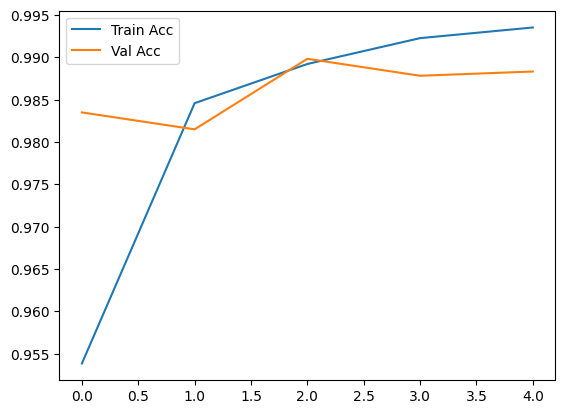

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()
